<a href="https://colab.research.google.com/github/rongione/anchorage_prediction/blob/main/anchorage_prediction_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean, stdev
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/boats_at_harbor/boats_at_harbor.csv")

# Data preparation

In [ ]:
df['datum'] = pd.to_datetime(df['datum'], utc=True)

df["windDirectionDegrees"] = pd.to_numeric(df["windDirectionDegrees"], errors="coerce")
df["windSpeedMps"] = pd.to_numeric(df["windSpeedMps"], errors="coerce")
df["temperatureCelsius"] = pd.to_numeric(df["temperatureCelsius"], errors="coerce")
df["boats_at_harbor"] = pd.to_numeric(df["boats_at_harbor"], errors="coerce")
df["day_of_week"] = pd.to_numeric(df["day_of_week"], errors="coerce")
df["precipitationMm"] = pd.to_numeric(df["precipitationMm"], errors="coerce")

# Feature engineering

### Hour cos and sin

In [ ]:
df['hour'] = df['datum'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

### Wind cos and sin

In [ ]:
wind_rad = np.deg2rad(df['windDirectionDegrees'])
df["wind_dir_sin"] = np.sin(wind_rad)
df["wind_dir_cos"] = np.cos(wind_rad)

In [ ]:
# Verify rows
df.info()
df.head(40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921167 entries, 0 to 921166
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   datum                 921167 non-null  datetime64[ns, UTC]
 1   hamnId                921167 non-null  int64              
 2   boats_at_harbor       921167 non-null  int64              
 3   windSpeedMps          921167 non-null  float64            
 4   windDirectionDegrees  921167 non-null  float64            
 5   temperatureCelsius    921167 non-null  float64            
 6   precipitationMm       921167 non-null  float64            
 7   weatherType           921167 non-null  int64              
 8   day_of_week           921167 non-null  int64              
 9   hour                  921167 non-null  int32              
 10  hour_sin              921167 non-null  float64            
 11  hour_cos              921167 non-null  float64      

,datum,hamnId,boats_at_harbor,windSpeedMps,windDirectionDegrees,temperatureCelsius,precipitationMm,weatherType,day_of_week,hour,hour_sin,hour_cos,wind_dir_sin,wind_dir_cos
0,2025-08-31 00:00:00+00:00,131994,1,1.30,176.84,13.43,0.0,0,1,0,0.0,1.0,0.055124,-0.998479
1,2025-08-31 00:00:00+00:00,129109,1,2.08,105.73,15.87,0.0,3,1,0,0.0,1.0,0.962550,-0.271104
2,2025-08-31 00:00:00+00:00,830385,1,0.48,310.81,13.23,0.0,45,1,0,0.0,1.0,-0.756881,0.653553
3,2025-08-31 00:00:00+00:00,830831,1,5.10,168.92,15.04,0.0,2,1,0,0.0,1.0,0.192179,-0.981360
4,2025-08-31 00:00:00+00:00,127946,3,2.19,200.48,16.94,0.0,2,1,0,0.0,1.0,-0.349880,-0.936794
5,2025-08-31 00:00:00+00:00,128949,1,1.68,10.06,14.89,0.0,3,1,0,0.0,1.0,0.174679,0.984625
6,2025-08-31 00:00:00+00:00,830407,1,0.32,244.71,13.87,0.0,45,1,0,0.0,1.0,-0.904157,-0.427200
7,2025-08-31 00:00:00+00:00,831157,1,2.30,97.38,11.11,0.0,3,1,0,0.0,1.0,0.991716,-0.128449
8,2025-08-31 00:00:00+00:00,830458,1,0.73,179.12,14.34,0.0,45,1,0,0.0,1.0,0.015358,-0.999882
9,2025-08-31 00:00:00+00:00,830986,1,1.19,112.59,14.42,0.0,2,1,0,0.0,1.0,0.923277,-0.384134


### Hamnar med flest båtar

Följande kod kommer att gruppera data per hamn och räkna antalet båtar i varje hamn, och sedan visa de 100 hamnar med flest båtar.

In [ ]:
top_harbors = df.groupby('hamnId')['boats_at_harbor'].sum().nlargest(100)
display(top_harbors)
print(f"Antal hamnar i top_harbors: {len(top_harbors)}")

,boats_at_harbor
hamnId,
128861,21097
127946,12946
128981,10605
129003,9397
127975,9123
...,...
128181,2964
128478,2933
129011,2892


Antal hamnar i top_harbors: 100


# Korrelation mellan alla relevanta variabler och antal båtar

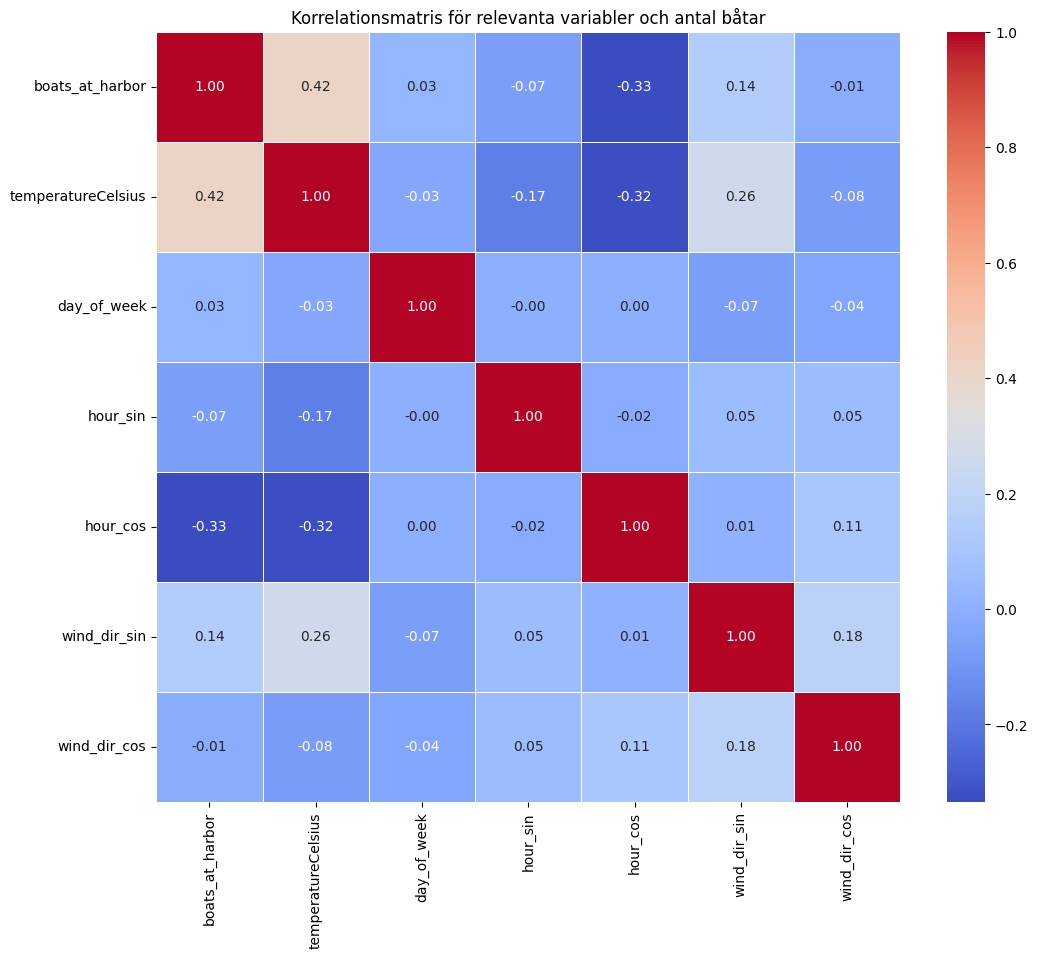

In [ ]:
top_harbor_ids = top_harbors.index

# Filtrera DataFrame för att endast inkludera data från de 100 största hamnarna
df_top_harbors = df[df['hamnId'].isin(top_harbor_ids)]

# Välj ut relevanta numeriska kolumner för korrelationsanalys
relevant_cols = [
    'boats_at_harbor',
    #'average_boats_at_harbor', # Borttagen för att förhindra dataläckage
    'temperatureCelsius',
    'day_of_week',
    'hour_sin',
    'hour_cos',
    'wind_dir_sin',
    'wind_dir_cos',
    #'boats_at_harbor_lag'
]

# Beräkna korrelationsmatrisen
correlation_matrix = df_top_harbors[relevant_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Korrelationsmatris för relevanta variabler och antal båtar')
plt.show()

# Beskrivning av hela datasetet

In [ ]:
# Shape of dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Data types
print("\nData types:")
print(df.dtypes)

# Saknade värden
print("\nMissing values per column:")
print(df.isnull().sum())

# Dubletter
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unique values in categorical columns
print("\nUnique values:")
for col in ["hamnId", "weatherType", "day_of_week"]:
    print(f"{col}: {df[col].nunique()} unique values")

# Check for invalid ranges
print("\nRange validation:")
print("Negative wind speeds:", (df["windSpeedMps"] < 0).sum())
print("Invalid wind directions:", ((df["windDirectionDegrees"] < 0) |
                                   (df["windDirectionDegrees"] > 360)).sum())
print("Negative precipitation:", (df["precipitationMm"] < 0).sum())

# Distubution av målvariabeln
print("\nBoat count distribution:")
print(df["boats_at_harbor"].value_counts().sort_index())

Rows: 921167, Columns: 14

Data types:
datum                   datetime64[ns, UTC]
hamnId                                int64
boats_at_harbor                       int64
windSpeedMps                        float64
windDirectionDegrees                float64
temperatureCelsius                  float64
precipitationMm                     float64
weatherType                           int64
day_of_week                           int64
hour                                  int32
hour_sin                            float64
hour_cos                            float64
wind_dir_sin                        float64
wind_dir_cos                        float64
dtype: object

Missing values per column:
datum                   0
hamnId                  0
boats_at_harbor         0
windSpeedMps            0
windDirectionDegrees    0
temperatureCelsius      0
precipitationMm         0
weatherType             0
day_of_week             0
hour                    0
hour_sin                0
hour_cos         

# Beskrivning av datasetet (Top 100 hamnar)

In [ ]:
# Shape of dataset
print(f"Rows: {df_top_harbors.shape[0]}, Columns: {df_top_harbors.shape[1]}")

# Data types
print("\nData types:")
print(df_top_harbors.dtypes)

# Saknade värden
print("\nMissing values per column:")
print(df_top_harbors.isnull().sum())

# Dubletter
print(f"\nDuplicate rows: {df_top_harbors.duplicated().sum()}")

# Summary statistics for numerical columns
print("\nNumerical summary:")
print(df_top_harbors.describe())

# Unique values in categorical columns
print("\nUnique values:")
for col in ["hamnId", "weatherType", "day_of_week"]:
    print(f"{col}: {df_top_harbors[col].nunique()} unique values")

# invalid ranges
print("\nRange validation:")
print("Negative wind speeds:", (df_top_harbors["windSpeedMps"] < 0).sum())
print("Invalid wind directions:", ((df_top_harbors["windDirectionDegrees"] < 0) |
                                   (df_top_harbors["windDirectionDegrees"] > 360)).sum())
print("Negative precipitation:", (df_top_harbors["precipitationMm"] < 0).sum())

# Distubution av målvariabeln
print("\nBoat count distribution:")
print(df_top_harbors["boats_at_harbor"].value_counts().sort_index())

Rows: 105036, Columns: 14

Data types:
datum                   datetime64[ns, UTC]
hamnId                                int64
boats_at_harbor                       int64
windSpeedMps                        float64
windDirectionDegrees                float64
temperatureCelsius                  float64
precipitationMm                     float64
weatherType                           int64
day_of_week                           int64
hour                                  int32
hour_sin                            float64
hour_cos                            float64
wind_dir_sin                        float64
wind_dir_cos                        float64
dtype: object

Missing values per column:
datum                   0
hamnId                  0
boats_at_harbor         0
windSpeedMps            0
windDirectionDegrees    0
temperatureCelsius      0
precipitationMm         0
weatherType             0
day_of_week             0
hour                    0
hour_sin                0
hour_cos         

# Konstruktion av attributet genomsnittlig beläggning (enbart på träningsdatat)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Välj ut relevanta funktioner och målvariabel
# Inkludera 'hamnId' och 'boats_at_harbor' temporärt i X för beräkning av medelantalet båtar, för att förhindra dataläckage
# boats_at_harbor kommer att tas bort från X_train och X_test efter beräkning av average_boats_at_harbor
features_for_split = [
    'hamnId',
    'boats_at_harbor', # Temporarily included for calculating average_boats_at_harbor
    'windSpeedMps',
    'temperatureCelsius',
    'day_of_week',
    'hour_sin',
    'hour_cos',
    'wind_dir_sin',
    'wind_dir_cos'
]
target = 'boats_at_harbor'

X = df_top_harbors[features_for_split] # Use the new list with boats_at_harbor
y = df_top_harbors[target]

# Dela upp data i tränings- och testset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Träningsset storlek: {len(X_train)} rader")
print(f"Testset storlek: {len(X_test)} rader")

Träningsset storlek: 84028 rader
Testset storlek: 21008 rader


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Beräkna 'average_boats_at_harbor' endast från träningsdata för att förhindra dataläckage
# Använd 'target' variabeln som referens för 'boats_at_harbor'
avg_boats_per_harbor = X_train.groupby('hamnId')[target].mean()

# Mappa dessa medelvärden till både tränings- och testsetet
X_train['average_boats_at_harbor'] = X_train['hamnId'].map(avg_boats_per_harbor)
X_test['average_boats_at_harbor'] = X_test['hamnId'].map(avg_boats_per_harbor)

# Calculate the mean of 'average_boats_at_harbor' from the training set
mean_avg_boats = X_train['average_boats_at_harbor'].mean()

print(X_test.describe())
# Hantera hamnar i testsetet som inte finns i träningssetet (sätt till medelvärdet)
X_test['average_boats_at_harbor'] = X_test['average_boats_at_harbor'].fillna(mean_avg_boats)


# Ta bort den temporära 'hamnId' kolumnen och den ursprungliga 'boats_at_harbor' från X_train och X_test
X_train = X_train.drop(columns=['hamnId', target]) # Drop 'target' (boats_at_harbor) from X_train
X_test = X_test.drop(columns=['hamnId', target])   # Drop 'target' (boats_at_harbor) from X_test

# Uppdatera till de slutgiltiga features för modellträningen
features = [
    'windSpeedMps',
    'temperatureCelsius',
    'day_of_week',
    'hour_sin',
    'hour_cos',
    'wind_dir_sin',
    'wind_dir_cos',
    'average_boats_at_harbor'
]

print("average_boats_at_harbor har beräknats och lagts till. hamnId och boats_at_harbor har tagits bort från X.")

              hamnId  boats_at_harbor  windSpeedMps  temperatureCelsius  \
count   21008.000000     21008.000000  21008.000000        21008.000000   
mean   199418.598915         4.542508      3.561327           18.154989   
std    209767.365325         4.901117      2.167704            2.939979   
min    127890.000000         1.000000      0.050000            6.090000   
25%    128149.000000         1.000000      1.960000           16.130000   
50%    128772.000000         3.000000      3.170000           18.000000   
75%    129011.000000         6.000000      4.750000           19.980000   
max    830483.000000        66.000000     16.090000           29.650000   

        day_of_week      hour_sin      hour_cos  wind_dir_sin  wind_dir_cos  \
count  21008.000000  21008.000000  21008.000000  21008.000000  21008.000000   
mean       4.149134     -0.019329     -0.103706     -0.129490     -0.026856   
std        2.015291      0.722625      0.683177      0.684385      0.717060   
min     

# Standardisering

In [ ]:
# Initiera StandardScaler
scaler = StandardScaler()

# Anpassa scalern till träningsdata och transformera både tränings- och testdata
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Konvertera tillbaka till DataFrame för att behålla kolumnnamn
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

print("Data har standardiserats.")

Data har standardiserats.


### Träna den linjära regressionsmodellen

In [ ]:
# Initiera och träna modellen
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Modellen har tränats klart: LinearRegression.")

Modellen har tränats klart: LinearRegression.


### Träna RandomForest modellen

In [ ]:
# Initiera och träna modellen
regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)
regressor.fit(X_train_scaled, y_train)

print("Modellen har tränats klart: RandomForest.")

Modellen har tränats klart: RandomForest.


# Utvärdera RandomForest

In [ ]:
# Out-of-Bag Score: Measures how well the model
# generalizes on unseen samples, a low value indicates weaker generalization.
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred_rf = regressor.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Mean Absolute Error (MAE) (RandomForest): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE) (RandomForest): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE) (RandomForest): {rmse_rf:.2f}")
print(f"R-squared (R²) (RandomForest): {r2_rf:.2f}")

Out-of-Bag Score: 0.7365214955501
Mean Absolute Error (MAE) (RandomForest): 1.71
Mean Squared Error (MSE) (RandomForest): 6.42
Root Mean Squared Error (RMSE) (RandomForest): 2.53
R-squared (R²) (RandomForest): 0.73


# Utvärdera LinearRegression

In [ ]:
y_pred_lr = model.predict(X_test_scaled)

# Sätt negativa prediktioner till noll, eftersom antal båtar inte kan vara negativt
y_pred_lr[y_pred_lr < 0] = 0

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Mean Absolute Error (MAE) (LinearRegression): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE) (LinearRegression): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE) (LinearRegression): {rmse_lr:.2f}")
print(f"R-squared (R²) (LinearRegression): {r2_lr:.2f}")

Mean Absolute Error (MAE) (LinearRegression): 2.58
Mean Squared Error (MSE) (LinearRegression): 14.67
Root Mean Squared Error (RMSE) (LinearRegression): 3.83
R-squared (R²) (LinearRegression): 0.39


In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted (LinearRegression)': y_pred_lr, 'Predicted (RandomForest)': y_pred_rf})
display(results.head(40))

,Actual,Predicted (LinearRegression),Predicted (RandomForest)
382262,3,5.368791,4.23
850740,4,4.022045,3.67
402501,2,3.190411,3.10
435199,12,8.787872,11.85
578024,10,4.302352,5.66
30515,6,4.462482,3.40
154986,6,6.033722,4.65
725792,1,1.405933,1.97
228863,1,1.876612,1.38
612615,2,1.576068,2.66


# Scatter plot (Linjär Regression)

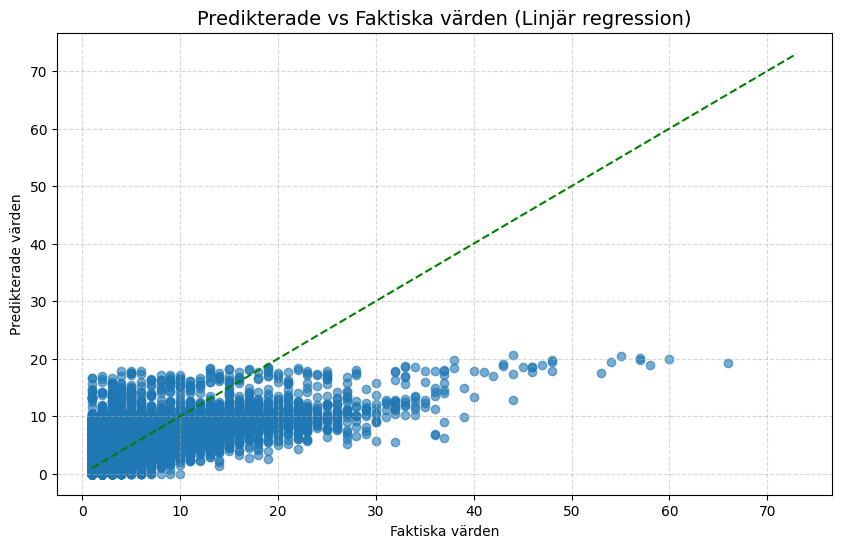

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x=results['Actual'], y=results['Predicted (LinearRegression)'], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='green', linestyle='--') # Perfekt förutsägelselinje
plt.xlabel('Faktiska värden')
plt.title('Predikterade vs Faktiska värden (Linjär regression)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Predikterade värden')
plt.show()

# Distribution av Residualer (Linjär Regression)

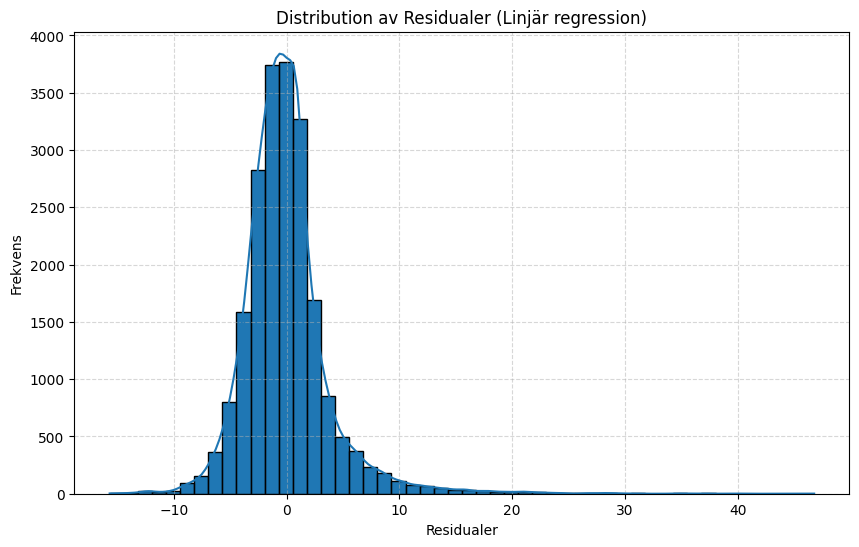

In [ ]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(10, 6))
plt.hist(residuals_lr, bins=50)
sns.histplot(residuals_lr, kde=True, bins=50)
plt.title('Distribution av Residualer (Linjär regression)')
plt.xlabel('Residualer')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Frekvens')
plt.show()

# Scatter plot (RandomForest)

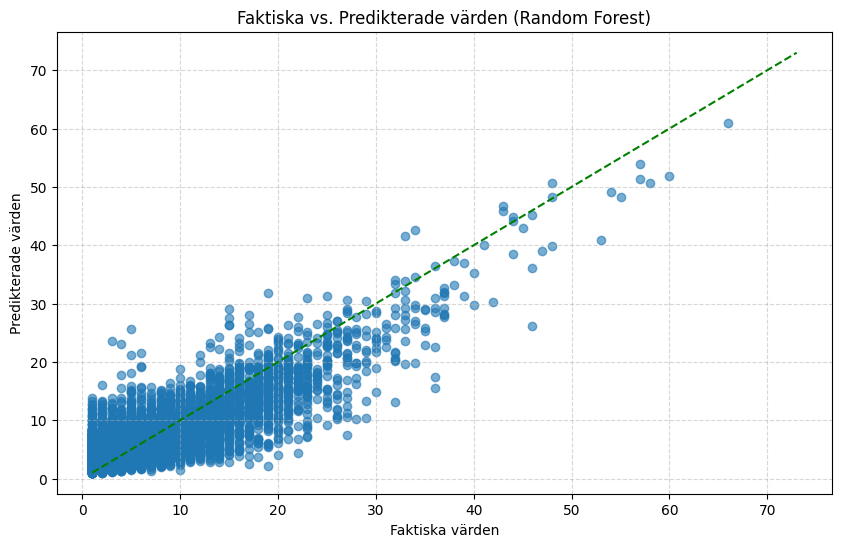

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x=results['Actual'], y=results['Predicted (RandomForest)'], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='green', linestyle='--') # Perfekt förutsägelselinje
plt.title('Faktiska vs. Predikterade värden (Random Forest)')
plt.xlabel('Faktiska värden')
plt.ylabel('Predikterade värden')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Distribution av Residualer (RandomForest)




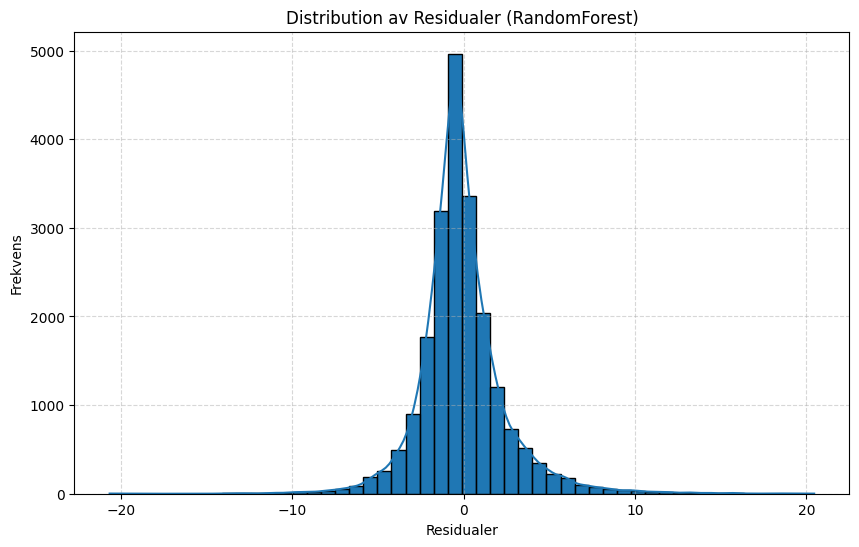

In [ ]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(10, 6))
plt.hist(residuals_rf, bins=50)
sns.histplot(residuals_rf, kde=True, bins=50)
plt.title('Distribution av Residualer (RandomForest)')
plt.xlabel('Residualer')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Frekvens')
plt.show()

### Fördelning av målvariabeln (hela datasetet)

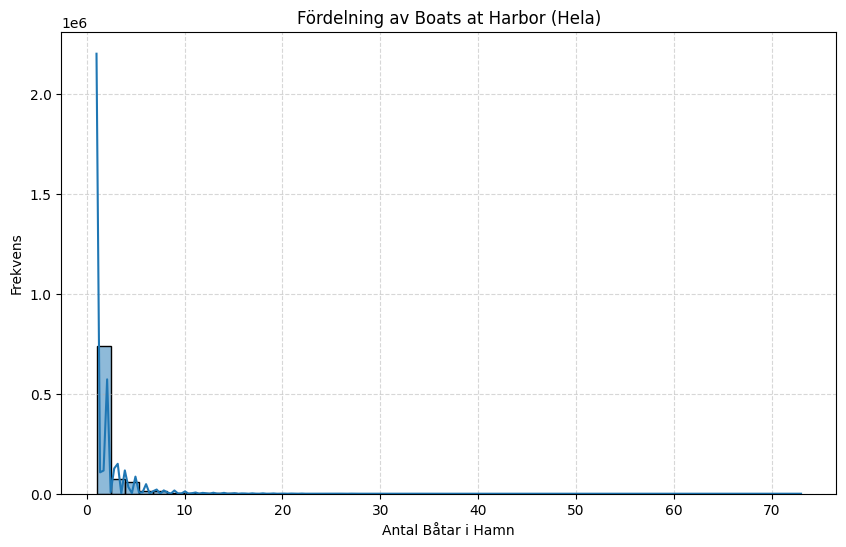

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['boats_at_harbor'], kde=True, bins=50)
plt.title('Fördelning av Boats at Harbor (Hela)')
plt.xlabel('Antal Båtar i Hamn')
plt.ylabel('Frekvens')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Fördelning av målvariabeln (Top 100 Hamnar)

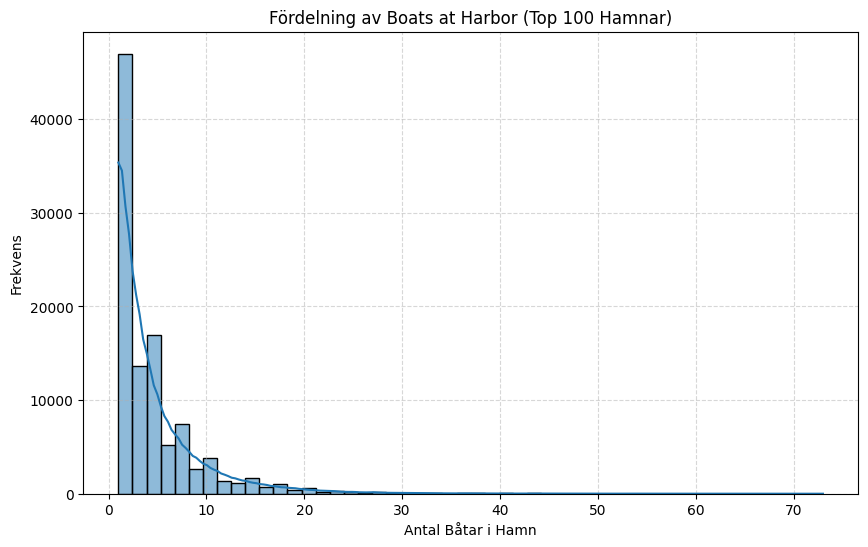

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_top_harbors['boats_at_harbor'], kde=True, bins=50)
plt.title('Fördelning av Boats at Harbor (Top 100 Hamnar)')
plt.xlabel('Antal Båtar i Hamn')
plt.ylabel('Frekvens')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Toppfunktioner från RandomForest-modellen

Detta diagram visar de viktigaste funktionerna som används av RandomForest-modellen för att göra förutsägelser.

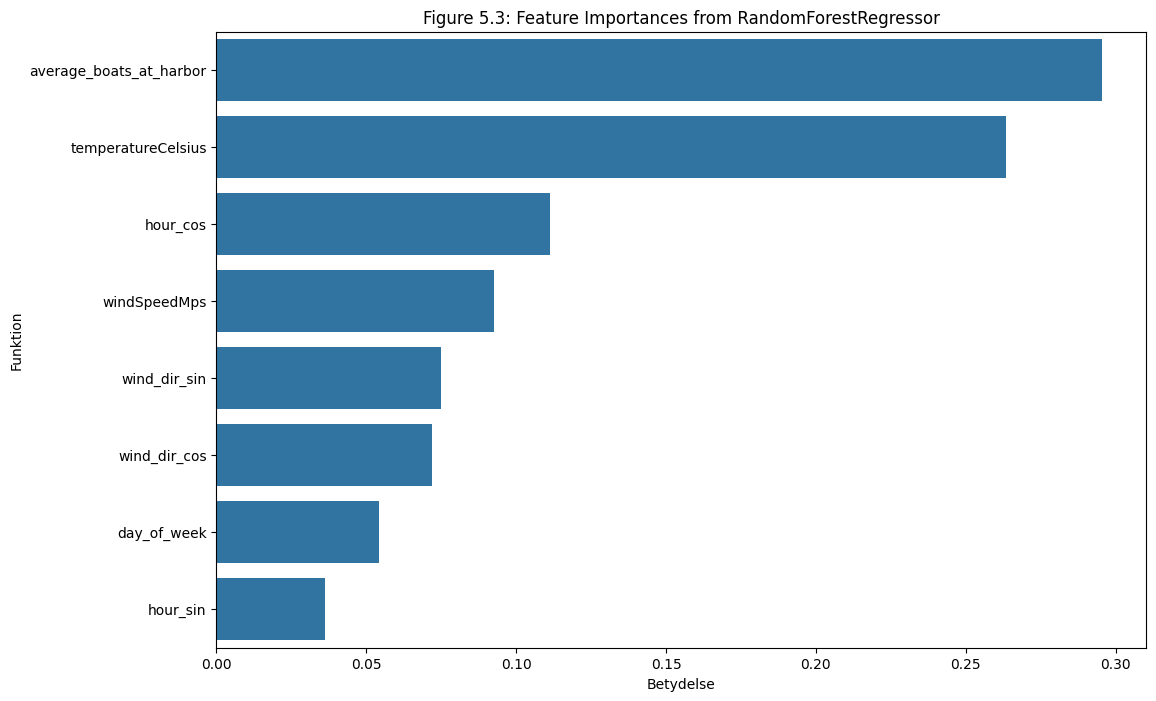

In [ ]:
feature_importances = regressor.feature_importances_
features_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Figure 5.3: Feature Importances from RandomForestRegressor')
plt.xlabel('Betydelse')
plt.ylabel('Funktion')
plt.show()